# 颱風路徑類比預測 — Coastline RRF

以歷史颱風為樣本做類比預測：在台灣海岸線外擴一定範圍內，比對查詢路徑與歷史路徑的相似度，投票得出侵臺路徑分類。

演算法 coastline_rrf 用 RRF 融合三個排名訊號：海岸線絕對位置（權重 0.80）、KNN 特徵（0.20）、可選降水（0.08）。

結構說明：
- 可調參數集中在 `Configuration`（`typhoon_predictor_lib/config.py`），在下方建立並覆寫。
- 函數依職責拆分在 `typhoon_predictor_lib/` 套件：config / geometry / data_loader / features / similarity / visualization / pipeline。
- 主入口：`predict_typhoons`

核心參數 `buffer_kilometers` = 計算範圍（海岸線外擴公里數）。

資料檔：typhoons_overview.json。

## 0. 匯入

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path

from typhoon_predictor_lib import (
    Configuration,
    leave_one_out_accuracy,
    load_records,
    plot_prediction,
    predict_typhoons,
    predict_typhoons_over_buffers,
)

## 1. 參數設定

在這裡覆寫所需欄位，未列出的沿用 `Configuration` 預設值。
個別預測也可在 `predict_typhoons(...)` 用 `buffer_kilometers` / `use_rainfall` 覆寫。

In [2]:
configuration = Configuration(
    buffer_kilometers=500,  # 計算範圍：海岸線外擴公里數
    neighbor_count=5,  # 取最相似的前幾條颱風
    use_rainfall=False,  # 是否納入降水訊號
    rainfall_region="tn",  # 降水地區：tn=臺南, kh=高雄
    data_path="typhoons_overview.json",  # 參考資料檔（與本 notebook 同目錄）
)
print(
    "設定完成 | 計算範圍: 海岸線外擴",
    configuration.buffer_kilometers,
    "km | neighbor_count =",
    configuration.neighbor_count,
    "| 資料檔 =",
    configuration.data_path,
)

設定完成 | 計算範圍: 海岸線外擴 500 km | neighbor_count = 5 | 資料檔 = typhoons_overview.json


## 2. 載入參考資料

載入有侵臺分類且軌跡點數 >= 2 的歷史颱風。

In [3]:
base_directory = Path.cwd()
records, categories_by_id = load_records(
    configuration.data_path, base_directory=base_directory
)
print("已載入", len(records), "筆參考颱風")

已載入 207 筆參考颱風


## 3. 查詢颱風路徑

每個點需要 `latitude` / `longitude`；`wind_kt` / `pressure_mb` 選填。

In [4]:
# 範例：西行穿越型
query_track = [
    {"latitude": 12.9, "longitude": 143.3},
    {"latitude": 13.4, "longitude": 142.0},
    {"latitude": 13.9, "longitude": 140.5},
    {"latitude": 13.9, "longitude": 138.6},
    {"latitude": 14.5, "longitude": 137.8},
    {"latitude": 14.3, "longitude": 136.7},
    {"latitude": 14.6, "longitude": 135.5},
    {"latitude": 15.0, "longitude": 134.4},
    {"latitude": 15.6, "longitude": 133.2},
    {"latitude": 16.1, "longitude": 131.8},
    {"latitude": 16.7, "longitude": 130.6},
    {"latitude": 16.9, "longitude": 128.8},
    {"latitude": 17.4, "longitude": 128.0},
    {"latitude": 17.9, "longitude": 126.9},
    {"latitude": 18.3, "longitude": 126.2},
    {"latitude": 18.7, "longitude": 125.7},
    {"latitude": 19.0, "longitude": 125.3},
    {"latitude": 19.4, "longitude": 125.0},
    {"latitude": 20.4, "longitude": 124.8},
    {"latitude": 21.5, "longitude": 125.0},
    {"latitude": 24.1, "longitude": 126.2},
    {"latitude": 27.2, "longitude": 129.1},
    {"latitude": 32.7, "longitude": 136.7}
]

In [5]:
# query_track = [
#     {"latitude": 15.0, "longitude": 135.0},
#     {"latitude": 18.0, "longitude": 129.0},
#     {"latitude": 21.0, "longitude": 124.0},
#     {"latitude": 22.5, "longitude": 122.0},
#     {"latitude": 24.0, "longitude": 120.5},
#     {"latitude": 25.5, "longitude": 119.5},
#     {"latitude": 27.0, "longitude": 119.0},
# ]

## 4. 使用案例

全部透過主入口 `predict_typhoons(configuration, query_track, records, ...)`，回傳預測分類、信心度、Top-K 相似颱風與表格。

### 案例 (i)：計算範圍 500km

In [6]:
prediction_500km = predict_typhoons(
    configuration, query_track, records, buffer_kilometers=500
)
print(
    f"[500km] 預測類型 {prediction_500km['predicted']}"
    f"（信心度 {prediction_500km['confidence'] * 100:.1f}%）"
)
prediction_500km["table"]

[500km] 預測類型 6（信心度 80.1%）


,id,颱風,年份,侵臺分類,平均偏離(km),相似度(%)
0,202211,軒嵐諾 (HINNAMNOR),2022,6,105.0,49.7
1,197909,歐敏 (IRVING),1979,6,201.3,26.1
2,201312,潭美 (TRAMI),2013,1,183.6,29.4
3,198212,西仕 (CECIL),1982,6,187.6,28.6
4,200012,巴比侖 (PRAPIROON),2000,6,209.5,24.7


### 案例 (ii)：計算範圍 500km，並納入降水訊號

`use_rainfall=True` 時需提供 `query_rainfall`（查詢颱風的事件降水量，單位 mm，地區由 `configuration.rainfall_region` 決定）。

In [7]:
prediction_500km_rainfall = predict_typhoons(
    configuration,
    query_track,
    records,
    buffer_kilometers=500,
    use_rainfall=True,
    query_rainfall=100,  # 查詢颱風預期事件降水量 (mm)
)
print(
    f"[500km+降水] 預測類型 {prediction_500km_rainfall['predicted']}"
    f"（信心度 {prediction_500km_rainfall['confidence'] * 100:.1f}%，"
    f"降水地區 {configuration.rainfall_region}）"
)
prediction_500km_rainfall["table"]

[500km+降水] 預測類型 6（信心度 80.3%，降水地區 tn）


,id,颱風,年份,侵臺分類,平均偏離(km),相似度(%)
0,197909,歐敏 (IRVING),1979,6,201.3,26.1
1,202211,軒嵐諾 (HINNAMNOR),2022,6,105.0,49.7
2,201312,潭美 (TRAMI),2013,1,183.6,29.4
3,198212,西仕 (CECIL),1982,6,187.6,28.6
4,200012,巴比侖 (PRAPIROON),2000,6,209.5,24.7


### 案例 (iii)：計算範圍 2000km

In [8]:
prediction_2000km = predict_typhoons(
    configuration, query_track, records, buffer_kilometers=2000
)
print(
    f"[2000km] 預測類型 {prediction_2000km['predicted']}"
    f"（信心度 {prediction_2000km['confidence'] * 100:.1f}%）"
)
prediction_2000km["table"]

[2000km] 預測類型 6（信心度 80.2%）


,id,颱風,年份,侵臺分類,平均偏離(km),相似度(%)
0,196912,芙勞西 (FLOSSIE),1969,6,170.0,32.2
1,200424,納坦 (NOCK-TEN),2004,6,177.9,30.5
2,202421,康芮 (KONG-REY),2024,3,178.2,30.5
3,199427,席斯 (SETH),1994,6,205.8,25.4
4,197909,歐敏 (IRVING),1979,6,249.1,19.0


## 5. 地圖視覺化

三個案例並排：台灣島、緩衝範圍、查詢路徑（紅）與 Top-K 相似路徑。

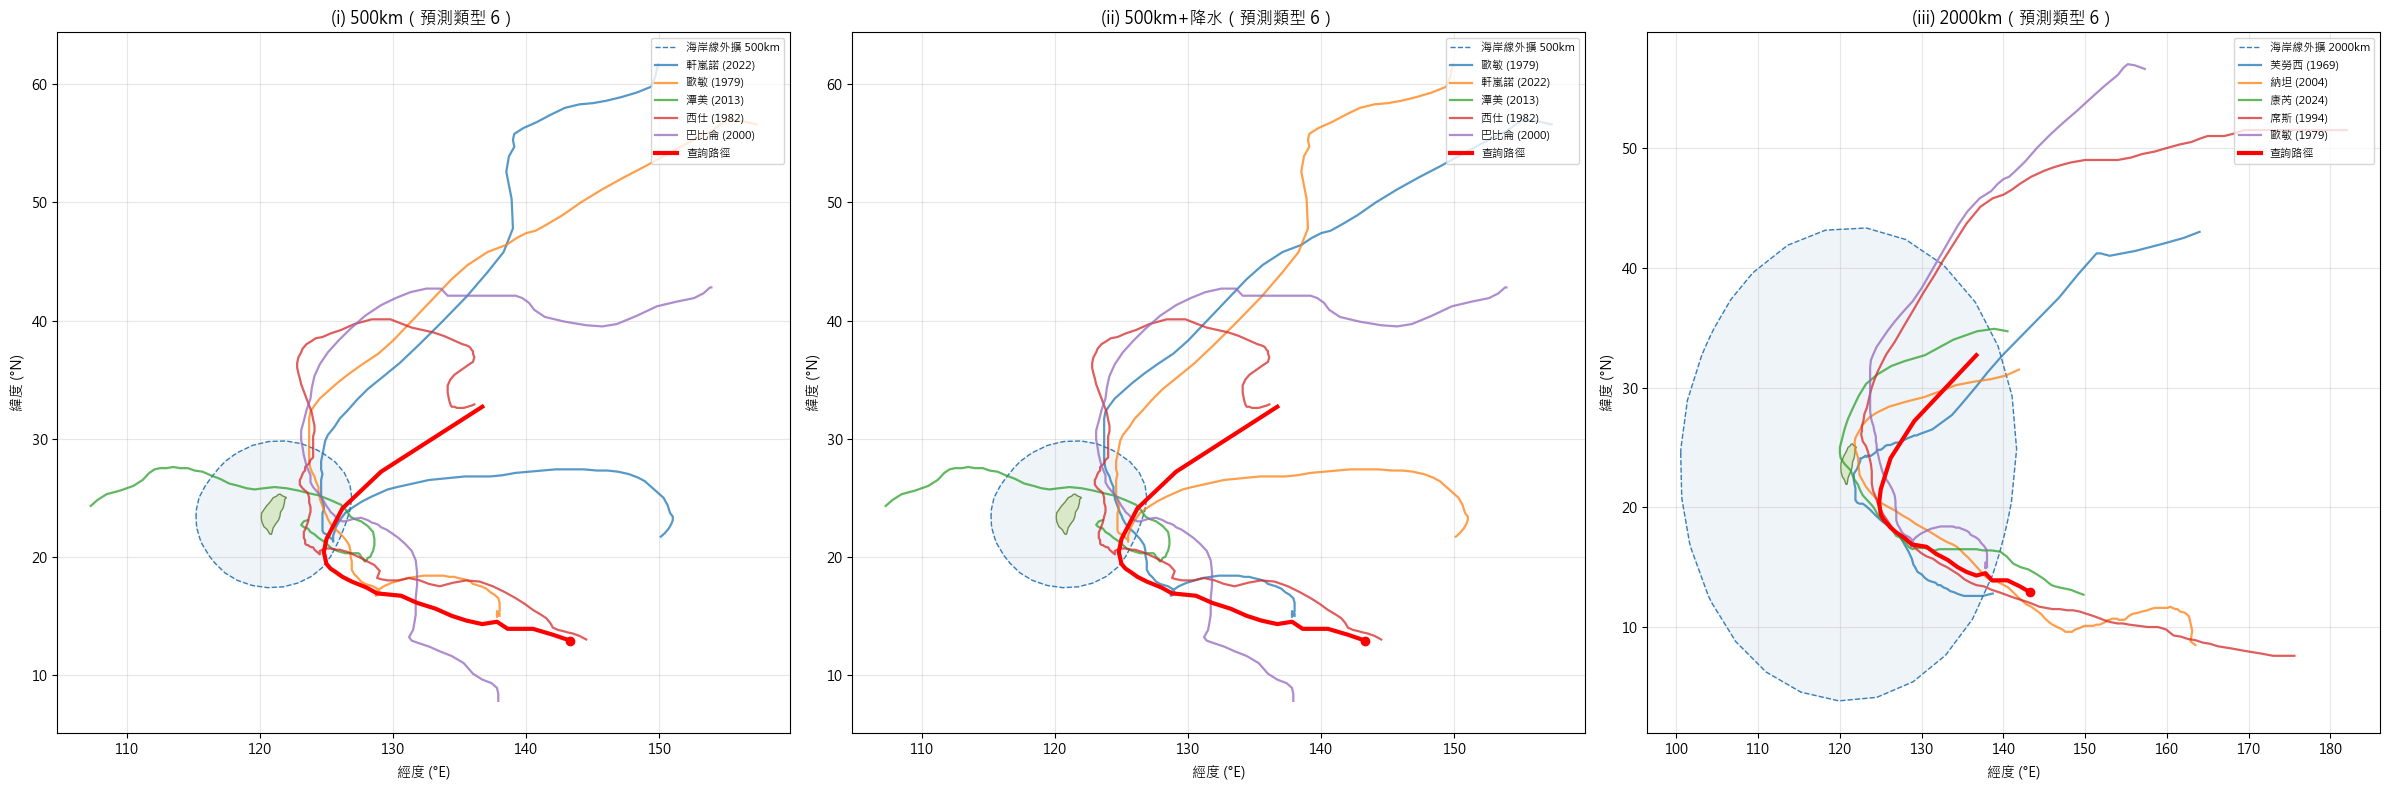

In [9]:
cases = [
    ("(i) 500km", prediction_500km),
    ("(ii) 500km+降水", prediction_500km_rainfall),
    ("(iii) 2000km", prediction_2000km),
]
figure, axes_list = plt.subplots(1, 3, figsize=(24, 8))
for axes, (case_title, prediction) in zip(axes_list, cases):
    plot_prediction(
        prediction["reference"],
        prediction["query_dataframe"],
        prediction,
        prediction["buffer_kilometers"],
        axes=axes,
        show=False,
    )
    axes.set_title(f"{case_title}（預測類型 {prediction['predicted']}）")
plt.tight_layout()
plt.show()